In [1]:
#%pip install flavio wilson iminuit matplotlib numpy scipy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from iminuit import Minuit
import flavio
from flavio.statistics.likelihood import FastLikelihood
from matplotlib.lines import Line2D

observables = [
    # Muy limpios y centrales
    'BR(Bs->mumu)',
    'BR(B0->mumu)',  # para evitar inconsistencia: algunas measurements constriñen ambos a la vez

    # LFU ratios (R_K y R_K* en bins típicos)
    ('<Rmue>(B+->Kll)', 1.1, 6.0),         # ~ R_K
    ('<Rmue>(B0->K*ll)', 0.045, 1.1),      # ~ R_K* low-q2
    ('<Rmue>(B0->K*ll)', 1.1, 6.0),        # ~ R_K* central-q2

    # Angular observable (P5') en región q2 donde QCDF es "más razonable"
    ('<P5p>(B0->K*mumu)', 4.0, 6.0),

    # Differential BR examples (en región baja q2)
    ('<dBR/dq2>(B+->Kmumu)', 1.1, 6.0),
    ('<dBR/dq2>(Bs->phimumu)', 1.1, 6.0),
]

In [3]:
# Centramos los parámetros del SM para el cálculo de la log-likelihood
par_central = flavio.default_parameters.get_central_all()

# Usamos FastLikelihood para crear la función de log-verosimilitud con los observables y parámetros definidos
fl = FastLikelihood('rareB_baseline', observables=observables, nuisance_parameters='all')

# Hacemos un test rápido para asegurarnos de que todo funciona y no hay errores de configuración
fl.make_measurement(N=3000, Nexp=3000, threads=1)

# Log-likelihood en el SM (WCs NP = 0)
wc_sm = flavio.WilsonCoefficients()    # SM => NP contribuciones = 0
ll_sm = fl.log_likelihood(par_central, wc_sm)
ll_sm

np.float64(56.19617846464786)

In [ ]:
def loglike_C9C10(C9, C10, scale=5.0):
    wc = flavio.WilsonCoefficients()
    wc.set_initial({'C9_bsmumu': C9, 'C10_bsmumu': C10}, scale)
    return fl.log_likelihood(par_central, wc)

def nll(C9, C10):
    return -loglike_C9C10(C9, C10)

m = Minuit(nll, C9=0.0, C10=0.0)
m.errordef = 0.5  # because NLL = -logL

# 1) Minimización
m.migrad()

# 2) Errores (Hesse) y (opcional) Minos
m.hesse()
m.minos()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -77.08                     │              Nfcn = 113              │
│ EDM = 6.09e-07 (Goal: 0.0001)    │           time = 70.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ C9   │   -0.33   │   0.16    │   -0.16    │    0.15    │         │         │       │
│ 1 │ C10  │   0.28    │   0.10    │   -0.10    │    0.10    │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┐
│          │          C9           │          C10          │
├──────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.16   │   0.15    │   -0.1    │    0.1    │
│  Valid   │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬───────────────┐
│     │     C9    C10 │
├─────┼───────────────┤
│  C9 │ 0.0243  0.010 │
│ C10 │  0.010 0.0093 │
└─────┴───────────────┘

In [5]:
print("\n=== Best-fit parameters (Hesse) ===")
# Tabla de parámetros
for p in m.params:
    # p: Parameter(name, value, error, ...)
    print(f"{p.name:6s} = {p.value:+.6f} ± {p.error:.6f}  (fixed={p.is_fixed})")

# Covarianza
cov = m.covariance # iminuit.util.Matrix
print("\n=== Covariance matrix ===")
print(cov) # imprime formato legible

# Correlaciones
print("\n=== Correlation matrix ===")
names = m.parameters
corr = np.array([[cov[a, b] / (np.sqrt(cov[a, a] * cov[b, b])) for b in names] for a in names])
header = "      " + " ".join([f"{n:>10s}" for n in names])
print(header)
for i, a in enumerate(names):
    row = " ".join([f"{corr[i,j]:10.3f}" for j in range(len(names))])
    print(f"{a:>6s} {row}")

print("\n=== MINOS ===")
for n in names:
    me = m.merrors[n]
    print(f"{n:6s}: -{abs(me.lower):.6f}  +{abs(me.upper):.6f}")


=== Best-fit parameters (Hesse) ===
C9     = -0.325469 ± 0.155974  (fixed=False)
C10    = +0.275249 ± 0.096429  (fixed=False)

=== Covariance matrix ===
┌─────┬───────────────┐
│     │     C9    C10 │
├─────┼───────────────┤
│  C9 │ 0.0243  0.010 │
│ C10 │  0.010 0.0093 │
└─────┴───────────────┘

=== Correlation matrix ===
              C9        C10
    C9      1.000      0.682
   C10      0.682      1.000

=== MINOS ===
C9    : -0.159147  +0.152991
C10   : -0.095115  +0.097804



=== SM Pull (Exacto) ===
Delta chi^2: 41.78
Grados de libertad (DOF): 2
p-value del SM: 8.47e-10
Pull del SM: 6.14 sigmas


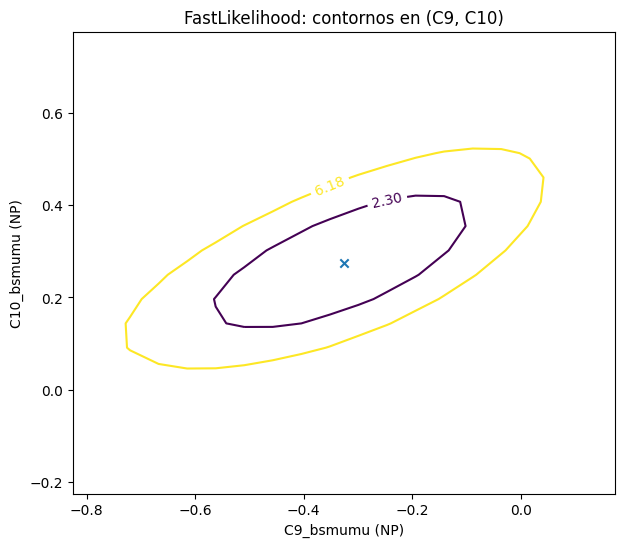

In [ ]:
# Escaneo 2D para contornos en Δχ² = -2(LL - LLmax)
C9_best, C10_best = m.values['C9'], m.values['C10']
ll_max = -m.fval

delta_chi2_sm = -2 * (ll_sm - ll_max)

# Definimos los grados de libertad
gl = 2  

# 1. Obtenemos el p-value desde la distribución chi-cuadrado (survival function)
p_value = stats.chi2.sf(delta_chi2_sm, df=gl)

# 2. Convertimos el p-value a sigmas (Z) usando la normal estándar inversa.
# Se divide el p-value entre 2 por convención (probabilidad de dos colas simétricas)
pull_exacto = stats.norm.isf(p_value / 2)

print("\n=== SM Pull (Exacto) ===")
print(f"Delta chi^2: {delta_chi2_sm:.2f}")
print(f"Grados de libertad (DOF): {gl}")
print(f"p-value del SM: {p_value:.2e}")
print(f"Pull del SM: {pull_exacto:.2f} sigmas")

In [ ]:
# 1. Definimos los grupos de observables
obs_br = [
    'BR(Bs->mumu)',
    'BR(B0->mumu)'
]

obs_leptones_lfu = [
    ('<Rmue>(B+->Kll)', 1.1, 6.0),
    ('<Rmue>(B0->K*ll)', 0.045, 1.1),
    ('<Rmue>(B0->K*ll)', 1.1, 6.0)
]

obs_muones = [
    ('<P5p>(B0->K*mumu)', 4.0, 6.0),
    ('<dBR/dq2>(B+->Kmumu)', 1.1, 6.0),
    ('<dBR/dq2>(Bs->phimumu)', 1.1, 6.0)
]

print("Inicializando FastLikelihoods por grupos")
fl_br = FastLikelihood('rareB_br', observables=obs_br, nuisance_parameters='all')
fl_br.make_measurement(N=3000, Nexp=3000, threads=1)

fl_lfu = FastLikelihood('rareB_lfu', observables=obs_leptones_lfu, nuisance_parameters='all')
fl_lfu.make_measurement(N=3000, Nexp=3000, threads=1)

fl_muon = FastLikelihood('rareB_muon', observables=obs_muones, nuisance_parameters='all')
fl_muon.make_measurement(N=3000, Nexp=3000, threads=1)

# Extremos del grid y resolución
n_points = 50
C9_grid = np.linspace(-2.0, 1.0, n_points)
C10_grid = np.linspace(-2.0, 1.0, n_points)

# Matrices para guardar la log-verosimilitud
Z_tot  = np.empty((len(C10_grid), len(C9_grid)))
Z_br   = np.empty((len(C10_grid), len(C9_grid)))
Z_lfu  = np.empty((len(C10_grid), len(C9_grid)))
Z_muon = np.empty((len(C10_grid), len(C9_grid)))

print(f"Evaluando el grid de {n_points}x{n_points} para los 4 likelihoods")
for i, C10 in enumerate(C10_grid):
    for j, C9 in enumerate(C9_grid):
        wc = flavio.WilsonCoefficients()
        wc.set_initial({'C9_bsmumu': C9, 'C10_bsmumu': C10}, 5.0)
        
        Z_tot[i, j]  = fl.log_likelihood(par_central, wc)
        Z_br[i, j]   = fl_br.log_likelihood(par_central, wc)
        Z_lfu[i, j]  = fl_lfu.log_likelihood(par_central, wc)
        Z_muon[i, j] = fl_muon.log_likelihood(par_central, wc)

print("Calculando los máximos reales con Minuit para evitar cortes en los contornos...")

# --- Minimizaciones lineales directas ---

# Para BR
def nll_br(C9, C10):
    wc = flavio.WilsonCoefficients()
    wc.set_initial({'C9_bsmumu': C9, 'C10_bsmumu': C10}, 5.0)
    return -fl_br.log_likelihood(par_central, wc)
m_br = Minuit(nll_br, C9=0.0, C10=0.0)
m_br.errordef = 0.5
m_br.migrad()
ll_max_br = -m_br.fval

# Para LFU
def nll_lfu(C9, C10):
    wc = flavio.WilsonCoefficients()
    wc.set_initial({'C9_bsmumu': C9, 'C10_bsmumu': C10}, 5.0)
    return -fl_lfu.log_likelihood(par_central, wc)
m_lfu = Minuit(nll_lfu, C9=0.0, C10=0.0)
m_lfu.errordef = 0.5
m_lfu.migrad()
ll_max_lfu = -m_lfu.fval

# Para Muones
def nll_muon(C9, C10):
    wc = flavio.WilsonCoefficients()
    wc.set_initial({'C9_bsmumu': C9, 'C10_bsmumu': C10}, 5.0)
    return -fl_muon.log_likelihood(par_central, wc)
m_muon = Minuit(nll_muon, C9=0.0, C10=0.0)
m_muon.errordef = 0.5
m_muon.migrad()
ll_max_muon = -m_muon.fval
ll_max_tot = np.max(Z_tot) 

# Convertimos a Delta chi^2 usando los verdaderos máximos en lugar de los bordes del grid
chi2_tot  = -2 * (Z_tot - ll_max_tot)
chi2_br   = -2 * (Z_br - ll_max_br)
chi2_lfu  = -2 * (Z_lfu - ll_max_lfu)
chi2_muon = -2 * (Z_muon - ll_max_muon)

Inicializando FastLikelihoods por grupos... (puede tardar unos segundos)
Evaluando el grid de 50x50 para los 4 likelihoods. Esto tomará un par de minutos...
Calculando los máximos reales con Minuit para evitar cortes en los contornos...


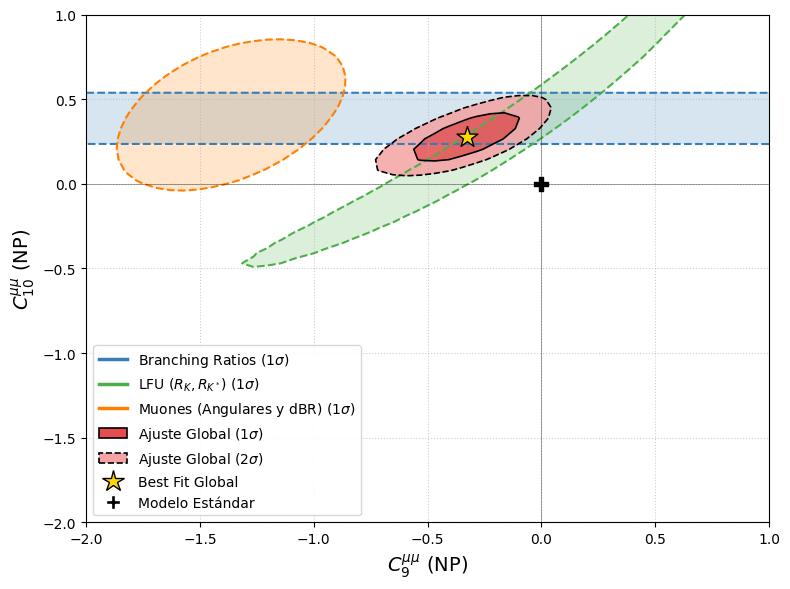

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# --- GRÁFICA ESTILO PAPER ---
fig, ax = plt.subplots(figsize=(8, 6))

level_1sigma = [2.30]
level_1sigma_fill = [0, 2.30] # Nuevo nivel para rellenar desde el centro hasta 1 sigma
levels_tot = [0, 2.30, 6.18]

# 1. OBSERVABLES INDIVIDUALES (Rellenos translúcidos de fondo)
# Dibujamos las áreas rellenas con un alpha bajito (0.2)
ax.contourf(C9_grid, C10_grid, chi2_br, levels=level_1sigma_fill, colors=['#377eb8'], alpha=0.2)   # Azul suave
ax.contourf(C9_grid, C10_grid, chi2_lfu, levels=level_1sigma_fill, colors=['#4daf4a'], alpha=0.2)  # Verde suave
ax.contourf(C9_grid, C10_grid, chi2_muon, levels=level_1sigma_fill, colors=['#ff7f00'], alpha=0.2) # Naranja suave

# Añadimos un borde fino discontinuo para que no queden como manchas sin forma
ax.contour(C9_grid, C10_grid, chi2_br, levels=level_1sigma, colors='#377eb8', linewidths=1.5, linestyles='--')
ax.contour(C9_grid, C10_grid, chi2_lfu, levels=level_1sigma, colors='#4daf4a', linewidths=1.5, linestyles='--')
ax.contour(C9_grid, C10_grid, chi2_muon, levels=level_1sigma, colors='#ff7f00', linewidths=1.5, linestyles='--')

# 2. AJUSTE GLOBAL (Contornos Rellenos - Dibujados encima para que destaquen)
ax.contourf(C9_grid, C10_grid, chi2_tot, levels=levels_tot, colors=['#E44C4E', '#F4A2A3'], alpha=0.85)
# Añadimos bordes finos a los contornos globales
ax.contour(C9_grid, C10_grid, chi2_tot, levels=[2.30, 6.18], colors=['black', 'black'], linestyles=['-', '--'], linewidths=1.2)

# 3. MARCADORES (Estrella dorada para BF y Cruz negra para SM)
ax.scatter([C9_best], [C10_best], marker='*', color='gold', edgecolor='black', s=250, zorder=10)
ax.scatter([0], [0], marker='P', color='black', s=100, zorder=10)

# 4. LEYENDA (Customizada para el nuevo diseño)
legend_elements = [
    Line2D([0], [0], color='#377eb8', lw=2.5, label=r'Branching Ratios ($1\sigma$)'),
    Line2D([0], [0], color='#4daf4a', lw=2.5, label=r'LFU ($R_K, R_{K^*}$) ($1\sigma$)'),
    Line2D([0], [0], color='#ff7f00', lw=2.5, label=r'Muones (Angulares y dBR) ($1\sigma$)'),
    mpatches.Patch(facecolor='#E44C4E', edgecolor='black', linewidth=1.2, label=r'Ajuste Global ($1\sigma$)'),
    mpatches.Patch(facecolor='#F4A2A3', edgecolor='black', linestyle='--', linewidth=1.2, label=r'Ajuste Global ($2\sigma$)'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gold', markeredgecolor='black', markersize=16, label='Best Fit Global'),
    Line2D([0], [0], marker='P', color='w', markerfacecolor='black', markersize=10, label='Modelo Estándar')
]

ax.legend(handles=legend_elements, loc='best', fontsize=10, framealpha=0.9, edgecolor='lightgray')

# 5. ESTÉTICA GENERAL DE LOS EJES
ax.set_xlabel(r'$C_9^{\mu\mu}$ (NP)', fontsize=14)
ax.set_ylabel(r'$C_{10}^{\mu\mu}$ (NP)', fontsize=14)
#ax.set_title('Ajuste Global 2D separado por familias de observables', fontsize=15, pad=15)

# Líneas de referencia sutiles en 0
ax.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

# Grid estilo artículo
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()